### Explorative Spatial Data Analysis

This notebook performs an exploratory spatial data analysis of New York City neighborhoods. The 2010 Neighborhood Tabulation Areas (NTAs) GeoJSON dataset is loaded with GeoPandas, inspected, and visualized. Neighborhood area and perimeter values are converted to numeric types and examined using histograms with logarithmic scales.

The notebook then loads a borough boundary dataset, compares its coordinate reference system with the neighborhood data, and reprojects the neighborhoods to match the borough boundaries. The datasets are overlaid to identify the neighborhoods contained within each borough. Neighborhood counts are calculated using both grouping and spatial overlay, then compared using a correlation matrix.

Finally, the borough and neighborhood boundaries are plotted together to visually compare the two spatial datasets.

In [1]:
import geopandas as gpd
from pathlib import Path

In [2]:
file_path = Path("../data/2010 Neighborhood Tabulation Areas (NTAs).geojson")

In [3]:
gdf = gpd.read_file(file_path)
gdf.head()

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ..."
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ..."
3,BK68,16482821.6487,047,Fort Greene,19825.5208594,Brooklyn,3,"MULTIPOLYGON (((-73.96939 40.69608, -73.96938 ..."
4,QN38,38835920.1944,081,Pomonok-Flushing Heights-Hillcrest,30731.4196253,Queens,4,"MULTIPOLYGON (((-73.7964 40.73828, -73.79639 4..."


In [4]:
gdf.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

<Axes: >

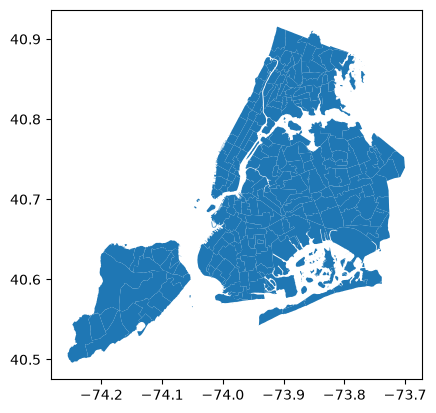

In [5]:
gdf.plot()

<Axes: >

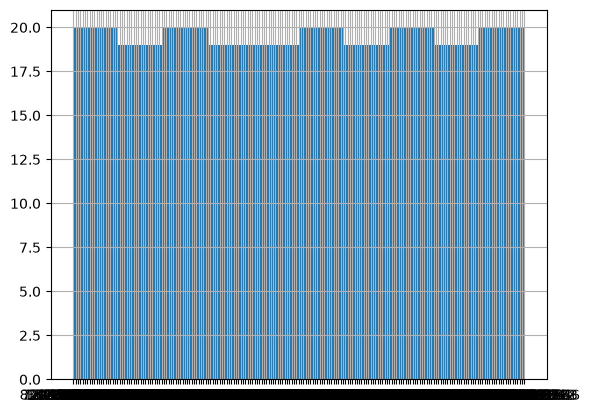

In [6]:
gdf.shape_area.hist()

In [7]:
print(type(gdf.shape_area.to_list()[0]))

<class 'str'>


In [8]:
gdf['shape_area'] = gdf['shape_area'].astype(float)
gdf['shape_leng'] = gdf['shape_leng'].astype(float)

In [9]:
print(type(gdf.shape_area.to_list()[0]))

<class 'float'>


Text(0.5, 1.0, 'NYC Neighborhood Area Shape Length')

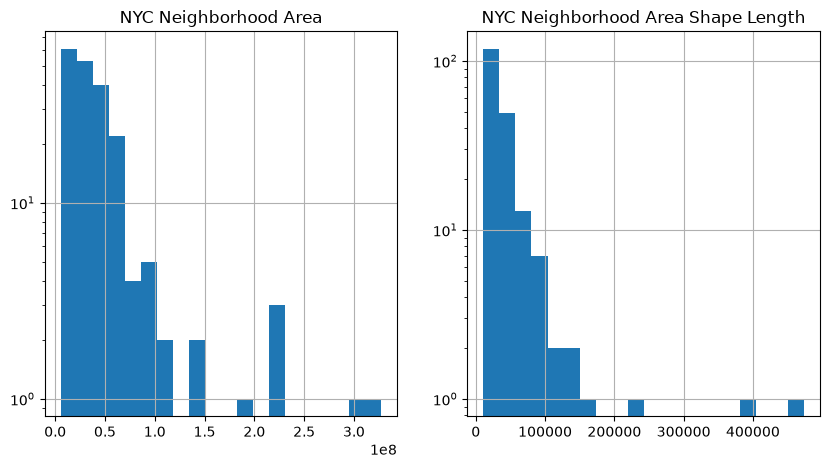

In [10]:
import matplotlib.pyplot as plt

f,ax = plt.subplots(1,2,figsize=(10,5))

gdf['shape_area'].hist(ax=ax[0], bins=20)
gdf['shape_leng'].hist(ax=ax[1], bins=20)

ax[0].set_yscale('log')
ax[1].set_yscale('log')

ax[0].set_title('NYC Neighborhood Area')
ax[1].set_title('NYC Neighborhood Area Shape Length')

#### Combine & compare spatial datasets

In [11]:
import geodatasets
from geodatasets import get_path

In [12]:
nybb = gpd.read_file(get_path('nybb'))
nybb.head()

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."
3,1,Manhattan,359299.096471,6.364715e+08,"MULTIPOLYGON (((981219.056 188655.316, 980940...."
4,2,Bronx,464392.991824,1.186925e+09,"MULTIPOLYGON (((1012821.806 229228.265, 101278..."


Text(0.5, 1.0, 'NYC Neighborhoods')

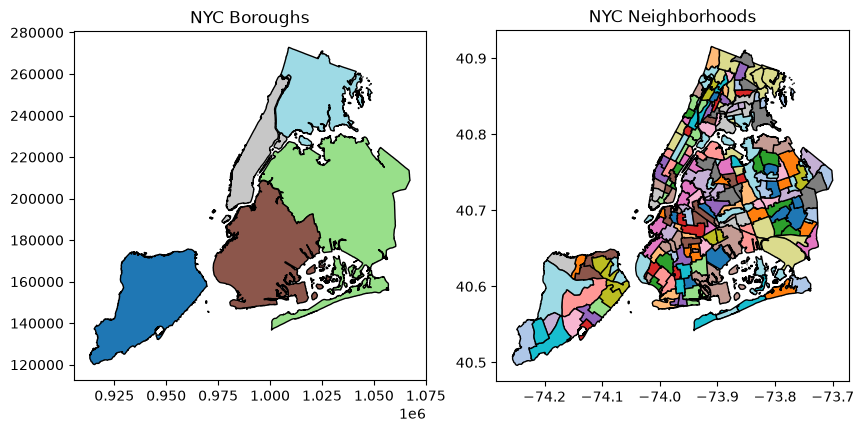

In [13]:
f,ax = plt.subplots(1,2,figsize=(10,5))

nybb.plot(ax=ax[0], cmap='tab20', edgecolor='black')
gdf.plot(ax=ax[1], cmap='tab20', edgecolor='black')

ax[0].set_title('NYC Boroughs')
ax[1].set_title('NYC Neighborhoods')

In [14]:
print(nybb.crs, gdf.crs)

EPSG:2263 EPSG:4326


In [15]:
gdf_local = gdf.to_crs(nybb.crs)
print(nybb.crs, gdf_local.crs)

EPSG:2263 EPSG:2263


In [16]:
gdf_local.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,7.741275e+07,081,St. Albans,45401.316915,Queens,4,"MULTIPOLYGON (((1052996.114 196307.361, 105308..."
1,BK50,8.208968e+07,047,Canarsie,43703.609937,Brooklyn,3,"MULTIPOLYGON (((1015236.113 174910.103, 101523..."
2,BX41,1.471671e+07,005,Mount Hope,18937.248075,Bronx,2,"MULTIPOLYGON (((1013128.551 250637.755, 101284..."


In [17]:
nybb.head(3)

,BoroCode,BoroName,Shape_Leng,Shape_Area,geometry
0,5,Staten Island,330470.010332,1.623820e+09,"MULTIPOLYGON (((970217.022 145643.332, 970227...."
1,4,Queens,896344.047763,3.045213e+09,"MULTIPOLYGON (((1029606.077 156073.814, 102957..."
2,3,Brooklyn,741080.523166,1.937479e+09,"MULTIPOLYGON (((1021176.479 151374.797, 102100..."


In [18]:
df_group_1 = gdf_local.groupby(by = 'boro_name').count()[['geometry']].rename(columns = {'geometry' : 'ngh_cnt_1'})
df_group_1

,ngh_cnt_1
boro_name,
Bronx,38
Brooklyn,51
Manhattan,29
Queens,58
Staten Island,19


In [19]:
gdf_over = gpd.overlay(nybb, gdf_local[['ntaname', 'geometry']])
gdf_over.head(3)

,BoroCode,BoroName,Shape_Leng,Shape_Area,ntaname,geometry
0,5,Staten Island,330470.010332,1.623820e+09,Charleston-Richmond Valley-Tottenville,"POLYGON ((922528.377 122455.996, 922528.29 122..."
1,5,Staten Island,330470.010332,1.623820e+09,Port Richmond,"MULTIPOLYGON (((944964.084 172610.981, 944984...."
2,5,Staten Island,330470.010332,1.623820e+09,New Dorp-Midland Beach,"POLYGON ((960370.525 147063.194, 960204.812 14..."


In [20]:
df_group_2 = gdf_over.groupby(by = 'BoroName').count()
df_group_2 = df_group_2[['ntaname']].rename(columns = {'ntaname' : 'ngh_cnt_2'})
df_group_2

,ngh_cnt_2
BoroName,
Bronx,39
Brooklyn,62
Manhattan,36
Queens,65
Staten Island,20


In [21]:
df_group = df_group_1.merge(df_group_2, left_index = True, right_index = True)
df_group

,ngh_cnt_1,ngh_cnt_2
boro_name,,
Bronx,38,39
Brooklyn,51,62
Manhattan,29,36
Queens,58,65
Staten Island,19,20


In [22]:
df_group.corr()

,ngh_cnt_1,ngh_cnt_2
ngh_cnt_1,1.000000,0.984094
ngh_cnt_2,0.984094,1.000000


<Axes: >

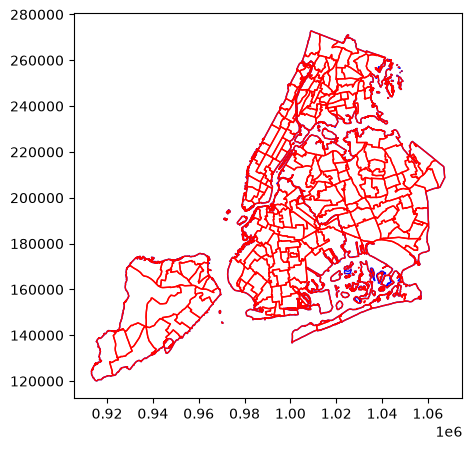

In [23]:
f,ax = plt.subplots(1,1,figsize=(10,5))
nybb.plot(ax=ax, color= 'None', edgecolor='blue')
gdf_local.plot(ax=ax, color= 'None', edgecolor='red')

In [24]:
print("Final insights:")
print(f"- The dataset contains {len(gdf)} NYC neighborhoods (NTAs).")
print("- Neighborhood area and perimeter values were converted from strings to floats.")
print("- Neighborhood sizes are highly skewed, with a few very large areas; logarithmic y-scales improve histogram readability.")
print(f"- The borough and neighborhood datasets use different CRS values, so neighborhoods were reprojected before spatial analysis.")
print(f"- Grouping by borough gives {df_group_1['ngh_cnt_1'].sum()} neighborhoods in total.")
print(f"- The spatial overlay returned {len(gdf_over)} intersection geometries, compared with {len(gdf)} original neighborhoods.")
print("- This difference reflects neighborhood geometries being split where they overlap or cross borough boundaries.")
print("- Both counting methods produce similar borough patterns, with Queens having the most neighborhoods and Staten Island the fewest.")
print(f"- The two counting approaches are strongly correlated (r = {df_group.corr().loc['ngh_cnt_1', 'ngh_cnt_2']:.3f}).")

Final insights:
- The dataset contains 195 NYC neighborhoods (NTAs).
- Neighborhood area and perimeter values were converted from strings to floats.
- Neighborhood sizes are highly skewed, with a few very large areas; logarithmic y-scales improve histogram readability.
- The borough and neighborhood datasets use different CRS values, so neighborhoods were reprojected before spatial analysis.
- Grouping by borough gives 195 neighborhoods in total.
- The spatial overlay returned 222 intersection geometries, compared with 195 original neighborhoods.
- This difference reflects neighborhood geometries being split where they overlap or cross borough boundaries.
- Both counting methods produce similar borough patterns, with Queens having the most neighborhoods and Staten Island the fewest.
- The two counting approaches are strongly correlated (r = 0.984).


In [25]:
import pandas as pd
df = pd.read_csv("../data/New_York_City_Population_By_Neighborhood_Tabulation_Areas_20240618.csv")

In [26]:
df.head()

,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,Bronx,2000,5,BX01,Claremont-Bathgate,28149
1,Bronx,2000,5,BX03,Eastchester-Edenwald-Baychester,35422
2,Bronx,2000,5,BX05,Bedford Park-Fordham North,55329
3,Bronx,2000,5,BX06,Belmont,25967
4,Bronx,2000,5,BX07,Bronxdale,34309


In [27]:
gdf = gpd.read_file('../data/2010 Neighborhood Tabulation Areas (NTAs).geojson')
print(len(gdf))

195


In [28]:
gdf.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ..."
1,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ..."
2,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ..."


In [34]:
codes_1 = set(df['NTA Code'])
codes_2 = set(gdf['ntacode'])

In [35]:
len(codes_1), len(codes_2), len(codes_1.intersection(codes_2))

(195, 195, 195)

In [38]:
gdf_merged = gdf.merge(df, right_on = 'NTA Code', left_on = 'ntacode')
gdf_merged.head()


,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2000,47,BK50,Canarsie,85058
3,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2010,47,BK50,Canarsie,83693
4,BX41,14716710.849,005,Mount Hope,18937.2480746,Bronx,2,"MULTIPOLYGON (((-73.89561 40.85457, -73.89662 ...",Bronx,2000,5,BX41,Mount Hope,52649


In [39]:
gdf_merged_1 = gdf_merged[['ntacode', 'geometry', 'Population']]
gdf_merged_1.head(3)

,ntacode,geometry,Population
0,QN08,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",50046
1,QN08,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",48593
2,BK50,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",85058


(np.float64(-74.28337047814922),
 np.float64(-73.67222994821337),
 np.float64(40.47516404814219),
 np.float64(40.93650271647436))

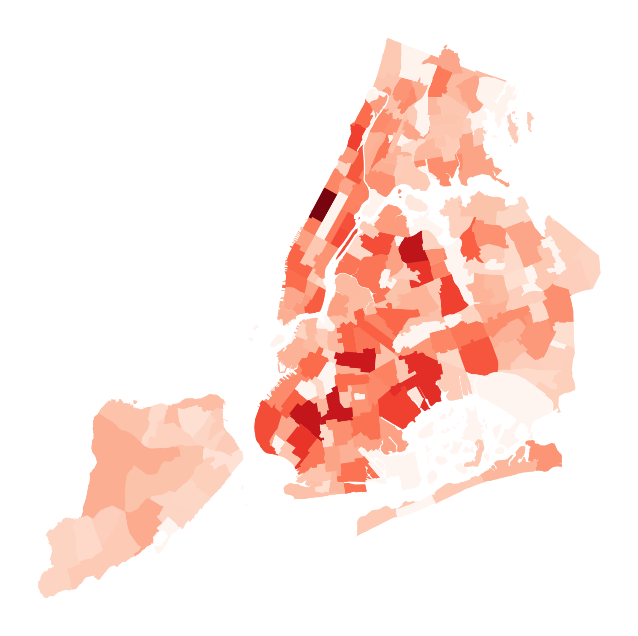

In [40]:
f, ax = plt.subplots(1,1,figsize=(8,8))

gdf_merged_1.plot(ax=ax, column = 'Population', cmap = 'Reds')
ax.axis('off')

In [57]:
# Summarize the 2010 Manhattan population data
manhattan_2010 = gdf_merged[
    (gdf_merged["boro_name"] == "Manhattan") &
    (gdf_merged["Year"] == 2010)
]

print(f"2010 Manhattan population: {manhattan_2010['Population'].sum():,}")
print(f"Number of Manhattan neighborhoods: {manhattan_2010['NTA Code'].nunique()}")

print("\nFive most populous neighborhoods:")
print(
    manhattan_2010.nlargest(5, "Population")[
        ["NTA Name", "Population"]
    ].to_string(index=False)
)

2010 Manhattan population: 1,585,873
Number of Manhattan neighborhoods: 29

Five most populous neighborhoods:
                         NTA Name  Population
                  Upper West Side      132378
         Washington Heights South       84438
      Lenox Hill-Roosevelt Island       80771
                        Yorkville       77942
Central Harlem North-Polo Grounds       75282


In [45]:
gdf_merged.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2000,81,QN08,St. Albans,50046
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,"MULTIPOLYGON (((-73.75205 40.70523, -73.75174 ...",Queens,2010,81,QN08,St. Albans,48593
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,"MULTIPOLYGON (((-73.88834 40.64671, -73.88835 ...",Brooklyn,2000,47,BK50,Canarsie,85058


In [44]:
gdf_manhattan = gdf_merged[gdf_merged.boro_name=='Manhattan']
gdf_manhattan.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
90,MN19,17390168.1386,061,Turtle Bay-East Midtown,21251.8414488,Manhattan,1,"MULTIPOLYGON (((-73.96052 40.74411, -73.96057 ...",Manhattan,2000,61,MN19,Turtle Bay-East Midtown,49737
91,MN19,17390168.1386,061,Turtle Bay-East Midtown,21251.8414488,Manhattan,1,"MULTIPOLYGON (((-73.96052 40.74411, -73.96057 ...",Manhattan,2010,61,MN19,Turtle Bay-East Midtown,51231
94,MN04,15984383.0261,061,Hamilton Heights,17103.3632867,Manhattan,1,"MULTIPOLYGON (((-73.94035 40.83046, -73.94014 ...",Manhattan,2000,61,MN04,Hamilton Heights,50555


In [46]:
gdf_manhattan_local = gdf_manhattan.to_crs(2263)
gdf_merged = gdf_merged.to_crs(2263)

<Axes: >

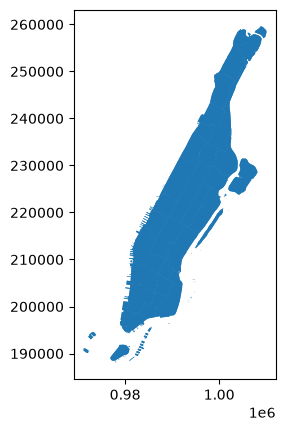

In [47]:
gdf_manhattan_local.plot()

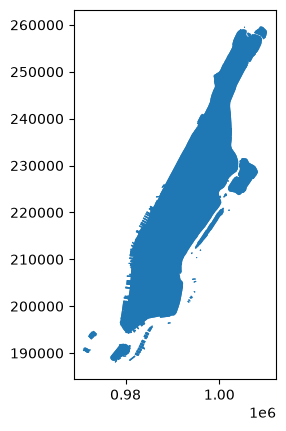

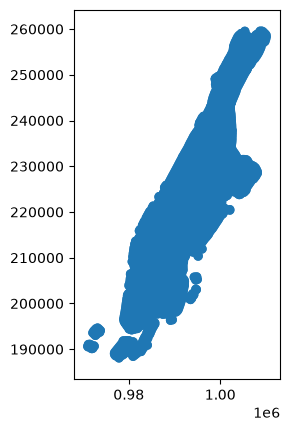

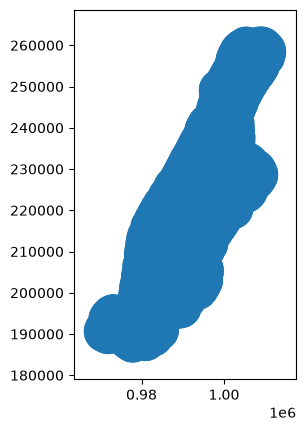

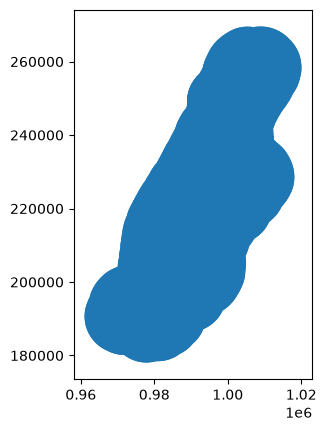

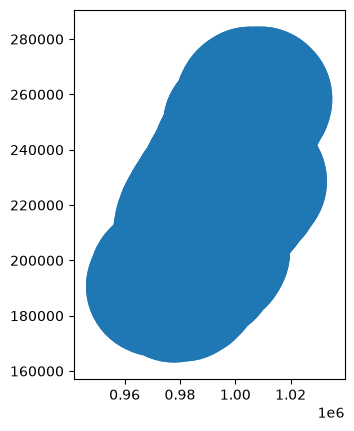

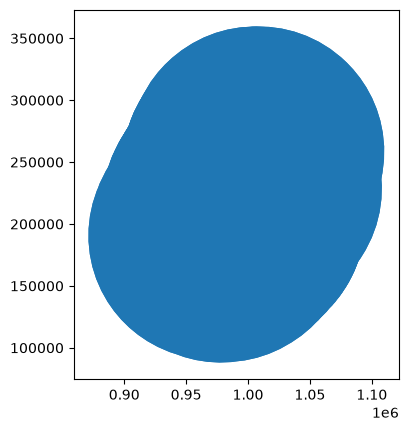

In [48]:
distances = [100, 1000, 5000, 10000, 25000, 100000]

for distance in distances:
    gdf_manhattan_local.buffer(distance).plot()

<Axes: >

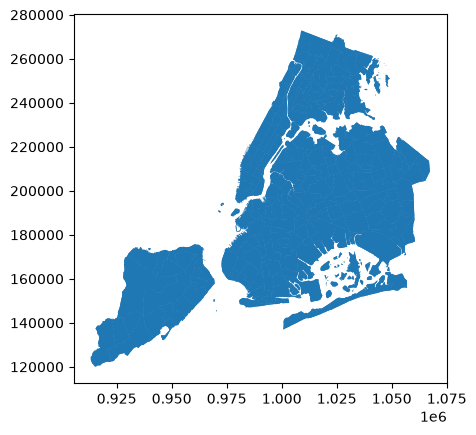

In [49]:
gdf_merged.plot()

In [50]:
gdf_merged_local_points = gdf_merged.copy()
gdf_merged_local_points['geometry'] = [g.centroid for g in list(gdf_merged_local_points.geometry)]
gdf_merged_local_points.head(3)

,ntacode,shape_area,county_fips,ntaname,shape_leng,boro_name,boro_code,geometry,Borough,Year,FIPS County Code,NTA Code,NTA Name,Population
0,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2000,81,QN08,St. Albans,50046
1,QN08,77412747.756,081,St. Albans,45401.3169155,Queens,4,POINT (1049933.65 191188.479),Queens,2010,81,QN08,St. Albans,48593
2,BK50,82089678.5561,047,Canarsie,43703.6099368,Brooklyn,3,POINT (1012073.055 171748.235),Brooklyn,2000,47,BK50,Canarsie,85058


<Axes: >

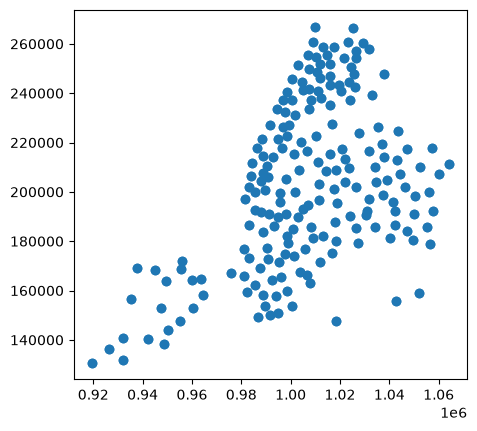

In [51]:
gdf_merged_local_points.plot()

<Axes: >

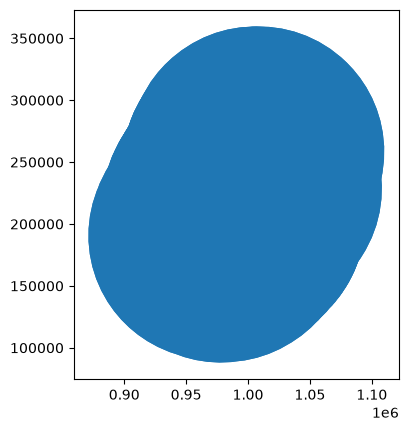

In [52]:
# buffering
distance = 100000
gdf_manhattan_local_buffered = gdf_manhattan_local.copy()
gdf_manhattan_local_buffered['geometry'] = gdf_manhattan_local_buffered['geometry'].buffer(distance)
gdf_manhattan_local_buffered.plot()

<Axes: >

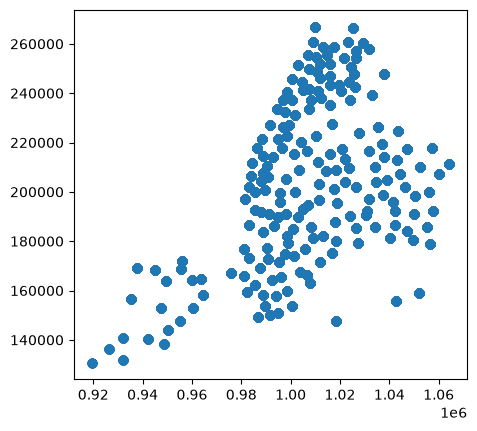

In [53]:
# spatial join
gdf_joined = gpd.sjoin(gdf_merged_local_points, gdf_manhattan_local_buffered)
gdf_joined.plot()

In [54]:
# compute population
print('Manhattan population: ', sum(gdf_joined.Population_left))
print('Buffer zone population: ', sum(gdf_joined.Population_right))
print('Population ratio: ', round(sum(gdf_joined.Population_left) / sum(gdf_joined.Population_right),2))

Manhattan population:  926925590
Buffer zone population:  1189058898
Population ratio:  0.78


In [55]:
def count_populaiton_stats(distance):
    
    # buffering
    gdf_manhattan_local_buffered = gdf_manhattan_local.copy()
    gdf_manhattan_local_buffered['geometry'] = gdf_manhattan_local_buffered['geometry'].buffer(distance)
    gdf_manhattan_local_buffered.plot()
    
    
    # spatial join
    gdf_joined = gpd.sjoin(gdf_merged_local_points, gdf_manhattan_local_buffered)
    
    
    # compute population
    print('Zone size: ', distance, ' feet')
    print('Manhattan population: ', sum(gdf_joined.Population_left))
    print('Buffer zone population: ', sum(gdf_joined.Population_right))
    print('Population ratio: ', round(sum(gdf_joined.Population_left) / sum(gdf_joined.Population_right),2))
    print()

Zone size:  100  feet
Manhattan population:  6246136
Buffer zone population:  6468716
Population ratio:  0.97

Zone size:  1000  feet
Manhattan population:  7073634
Buffer zone population:  7745976
Population ratio:  0.91

Zone size:  5000  feet
Manhattan population:  45086628
Buffer zone population:  45091396
Population ratio:  1.0

Zone size:  10000  feet
Manhattan population:  96690452
Buffer zone population:  99897392
Population ratio:  0.97

Zone size:  25000  feet
Manhattan population:  283775832
Buffer zone population:  312385952
Population ratio:  0.91

Zone size:  100000  feet
Manhattan population:  926925590
Buffer zone population:  1189058898
Population ratio:  0.78



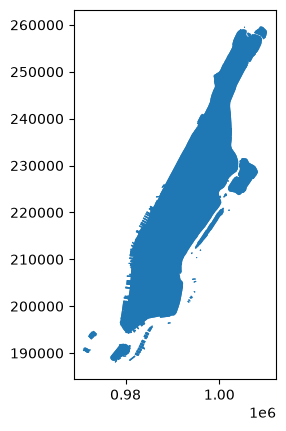

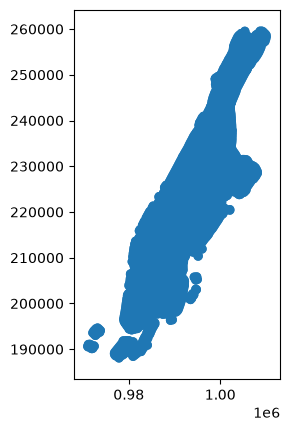

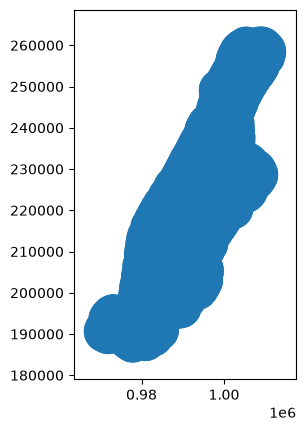

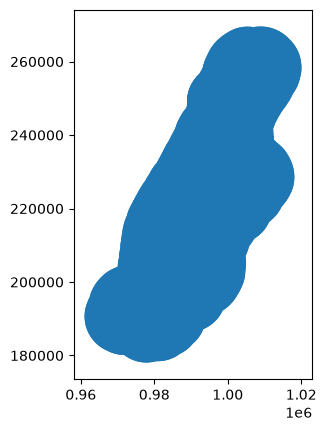

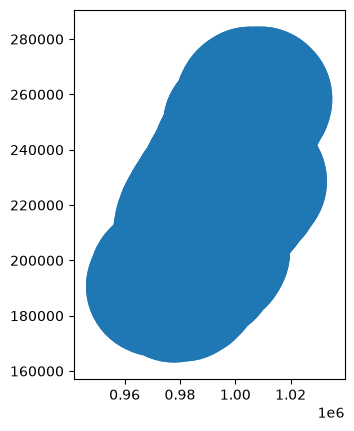

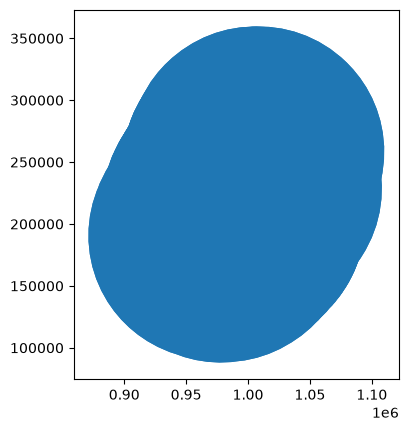

In [56]:
for distance in distances:
    count_populaiton_stats(distance)